# Time Series Forecasting Techniques

Imagine you are given asked to analyze climate data. Your employer has asked you to create a model to forcast tomorrows tempreture.

* What would have the most explanatory power in tomorrows weather?
    - Todays?

In [21]:
import pandas as pd
import statsmodels.api as sm

# Load the Vega dataset
df = pd.read_csv("https://raw.githubusercontent.com/stanfordnlp/plot-interface/master/public/data/sf-temps.csv")

# Set the date as the index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Calculate monthly average temperature
monthly_avg_temp = df.resample('M').mean()

# Display the first few rows of the monthly average temperature
monthly_avg_temp.head()


,temp
date,
2010-01-31,49.984140
2010-02-28,52.243899
2010-03-31,53.956528
2010-04-30,55.633056
2010-05-31,57.970968


In [25]:
from statsmodels.tsa.ar_model import AutoReg

# Ensure the data is appropriate for modeling
df['temp'] = df['temp'].dropna()  # Drop any missing values

# Fit an Autoregressive Model (AR model)
ar_model = AutoReg(df['temp'], lags=1)
ar_result = ar_model.fit()

print(ar_result.summary())

                            AutoReg Model Results                             
Dep. Variable:                   temp   No. Observations:                 8759
Model:                     AutoReg(1)   Log Likelihood              -14213.769
Method:               Conditional MLE   S.D. of innovations              1.226
Date:                Sun, 10 Dec 2023   AIC                          28433.539
Time:                        04:13:42   BIC                          28454.772
Sample:                             1   HQIC                         28440.774
                                 8759                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1606      0.123      9.446      0.000       0.920       1.401
temp.L1        0.9796      0.002    456.501      0.000       0.975       0.984
                                    Roots           

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


# Autoregressive (AR) Models

## What is an AR Model?
- An **Autoregressive (AR) model** is a type of statistical model used for forecasting in time series data.
- It predicts future behavior based on past behavior.
- The model is termed "autoregressive" because it regresses the variable against itself.

## Formulation of an AR Model
- The AR model is defined as:

$
Y_t = c + x_1 Y_{t-1} + x_2 Y_{t-2} + ... + x_p Y_{t-p} + \epsilon_t$

where,
- $Y_t$ is the value at time \( t \),
- $c$ is a constant,
- $x_1, x_2, ..., x_p$ are the parameters of the model,
- $p$ is the order of the AR model,
- $\epsilon_t$ is white noise.

## Moving Averages

Now imagine you're trying to understand the weather and predict what it will be like tomorrow. One way to do it is to look at how the weather has been changing over the past few days. The Moving Average (MA) model does something similar with data.

In an MA model, instead of looking directly at the data itself (like the temperature each day), we look at the "errors" made in previous predictions. "Error" here means how much we were off in our past predictions. For example, if we predicted yesterday's temperature would be 70°F, but it was actually 72°F, the error is 2°F.

The MA model says that the best prediction for today's temperature is a combination of these past errors. So, it's like saying, "I know I've been off by a few degrees in the past few days, let me use that information to make a better guess today."

In [51]:
### The MA model in action

ma_model = sm.tsa.ARIMA(df['temp'], order=(0, 0, 1))
ma_result = ma_model.fit()

# Display the summary of the MA model
print(ma_result.summary())

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                  261
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -519.291
Date:                Sun, 10 Dec 2023   AIC                           1044.582
Time:                        04:25:56   BIC                           1055.276
Sample:                    01-01-2010   HQIC                          1048.881
                         - 12-31-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         53.7023      0.219    244.736      0.000      53.272      54.132
ma.L1          0.9999      2.187      0.457      0.648      -3.287       5.287
sigma2         3.0652      6.658      0.460      0.6

# Moving Average (MA) Models

## What is an MA Model?
- A **Moving Average (MA) model** is a statistical approach used for forecasting time series data.
- It predicts future values based on the errors (differences between actual and predicted values) of past predictions.

## How Does It Work?
- Instead of using past values of the series directly, the MA model uses the past forecast errors.
- A forecast error is the difference between the actual value and the forecasted value at a previous time point.

## Model Formulation
- The MA model is defined as:

$Y_t = \mu + ε_t + θ_1 ε_{t-1} + θ_2 ε_{t-2} + ... + θ_q ε_{t-q}$


where,
- $Y_t$ is the value at time $t$,
- $\mu$ is the mean of the series,
- $ε_t$ is the forecast error at time `t`,
- $θ_1, θ_2, ..., θ_q$ are the parameters of the model,
- $q$ is the order of the MA model.

In [64]:

# Load the Vega dataset
df = pd.read_csv("https://raw.githubusercontent.com/stanfordnlp/plot-interface/master/public/data/co2-concentration.csv")

# Set the date as the index
df['date'] = pd.to_datetime(df['Date'])
df.set_index('date', inplace=True)

# Calculate monthly average temperature
monthly_avg_co = df.resample('M').mean()

# Display the first few rows of the monthly average temperature
monthly_avg_co = monthly_avg_co.diff()


In [66]:
### The MA model in action

ma_model = sm.tsa.ARIMA(monthly_avg_co['CO2'], order=(0, 0, 1))
ma_result = ma_model.fit()

# Display the summary of the MA model
print(ma_result.summary())

                               SARIMAX Results                                
Dep. Variable:                    CO2   No. Observations:                  718
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -954.382
Date:                Sun, 10 Dec 2023   AIC                           1914.765
Time:                        04:35:27   BIC                           1928.494
Sample:                    03-31-1958   HQIC                          1920.066
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1292      0.061      2.130      0.033       0.010       0.248
ma.L1          0.6628      0.030     22.203      0.000       0.604       0.721
sigma2         0.8618      0.061     14.226      0.0

## Autoregressive Integrated Moving Average (ARIMA) models

Now we can talk both models, and combine them. Meaning, we can model both the error term and the moving average.

In [5]:
import pandas as pd

# Load the Vega dataset
df = pd.read_csv("https://raw.githubusercontent.com/stanfordnlp/plot-interface/master/public/data/co2-concentration.csv")

# Set the date as the index
df['date'] = pd.to_datetime(df['Date'])
df.set_index('date', inplace=True)

# Calculate monthly average temperature
monthly_avg_co = df.resample('M').mean()

# Display the first few rows of the monthly average temperature
monthly_avg_co = monthly_avg_co.diff()


In [9]:
import statsmodels.api as sm


ma_model = sm.tsa.ARIMA(monthly_avg_co['CO2'], order=(1, 0, 1))
ma_result = ma_model.fit()

# Display the summary of the MA model
print(ma_result.summary())

                               SARIMAX Results                                
Dep. Variable:                    CO2   No. Observations:                  718
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -884.455
Date:                Tue, 12 Dec 2023   AIC                           1776.909
Time:                        17:45:45   BIC                           1795.215
Sample:                    03-31-1958   HQIC                          1783.977
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1336      0.099      1.351      0.177      -0.060       0.327
ar.L1          0.5469      0.043     12.862      0.000       0.464       0.630
ma.L1          0.3727      0.048      7.800      0.0

# Seasonal ARIMA (SARIMA)

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Load the Vega dataset
df = pd.read_csv("https://raw.githubusercontent.com/stanfordnlp/plot-interface/master/public/data/co2-concentration.csv")

# Set the date as the index and convert to datetime
df['date'] = pd.to_datetime(df['Date'])
df.set_index('date', inplace=True)

# Resample to monthly average and take the first difference to make it stationary
monthly_avg_co = df.resample('M').mean()
monthly_avg_co_diff = monthly_avg_co.diff().dropna()

<AxesSubplot:xlabel='date'>

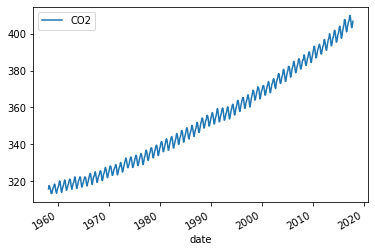

In [15]:
df.plot()

In [ ]:

# Define the SARIMA model - adjust p, d, q and seasonal_order parameters as needed
# Example parameters: p=1, d=1, q=1 for the non-seasonal part; 
# P=1, D=1, Q=1, s=12 for the seasonal part (assuming yearly seasonality)
model = sm.tsa.SARIMAX(monthly_avg_co_diff, 
                       order=(1, 1, 1), 
                       seasonal_order=(1, 1, 1, 12))

# Fit the model
sarima_result = model.fit()

# Display the summary of the model
print(sarima_result.summary())
